In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import GridSearchCV, cross_val_score
import math, time

In [2]:
train = pd.read_csv("EX_3/train.csv")
test = pd.read_csv("EX_3/test.csv")
print("Train Head\n", train.head())
print("Test Head\n", test.head())

print("Train Shape\n", train.shape)
print("Test Shape\n", test.shape)

Train Head
   Customer ID               Name Gender  Age  Income (USD) Income Stability  \
0     C-36995   Frederica Shealy      F   56       1933.05              Low   
1     C-33999  America Calderone      M   32       4952.91              Low   
2      C-3770      Rosetta Verne      F   65        988.19             High   
3     C-26480         Zoe Chitty      F   65           NaN             High   
4     C-23459       Afton Venema      F   31       2614.77              Low   

  Profession     Type of Employment    Location  Loan Amount Request (USD)  \
0    Working            Sales staff  Semi-Urban                   72809.58   
1    Working                    NaN  Semi-Urban                   46837.47   
2  Pensioner                    NaN  Semi-Urban                   45593.04   
3  Pensioner                    NaN       Rural                   80057.92   
4    Working  High skill tech staff  Semi-Urban                  113858.89   

   ...  Credit Score No. of Defaults Has Act

In [3]:
print("Train Null Values\n", train.isnull().sum())
print("Describe\n", train.describe())

print("Test Null Values\n", test.isnull().sum())

Train Null Values
 Customer ID                       0
Name                              0
Gender                           53
Age                               0
Income (USD)                   4576
Income Stability               1683
Profession                        0
Type of Employment             7270
Location                          0
Loan Amount Request (USD)         0
Current Loan Expenses (USD)     172
Expense Type 1                    0
Expense Type 2                    0
Dependents                     2493
Credit Score                   1703
No. of Defaults                   0
Has Active Credit Card         1566
Property ID                       0
Property Age                   4850
Property Type                     0
Property Location               356
Co-Applicant                      0
Property Price                    0
Loan Sanction Amount (USD)      340
dtype: int64
Describe
                 Age  Income (USD)  Loan Amount Request (USD)  \
count  30000.000000  2.542400e

In [5]:
target_col = "Loan Sanction Amount (USD)"

# Drop rows with NaN target
train = train.dropna(subset=[target_col])

In [6]:
train.shape

(29660, 24)

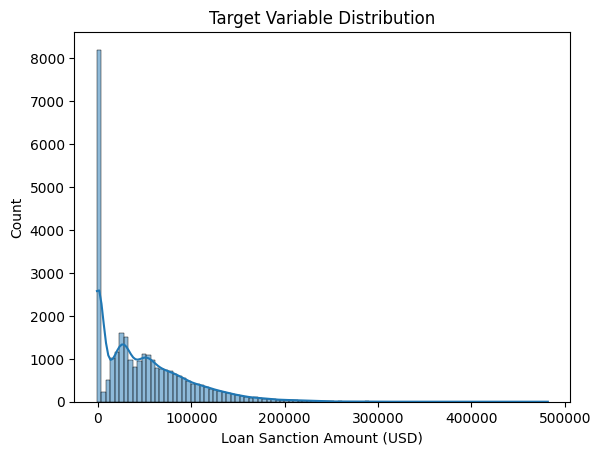

In [8]:
sns.histplot(train["Loan Sanction Amount (USD)"], kde=True)
plt.title("Target Variable Distribution")
plt.savefig("EX_3/targetDist.png", dpi=150)
plt.show()

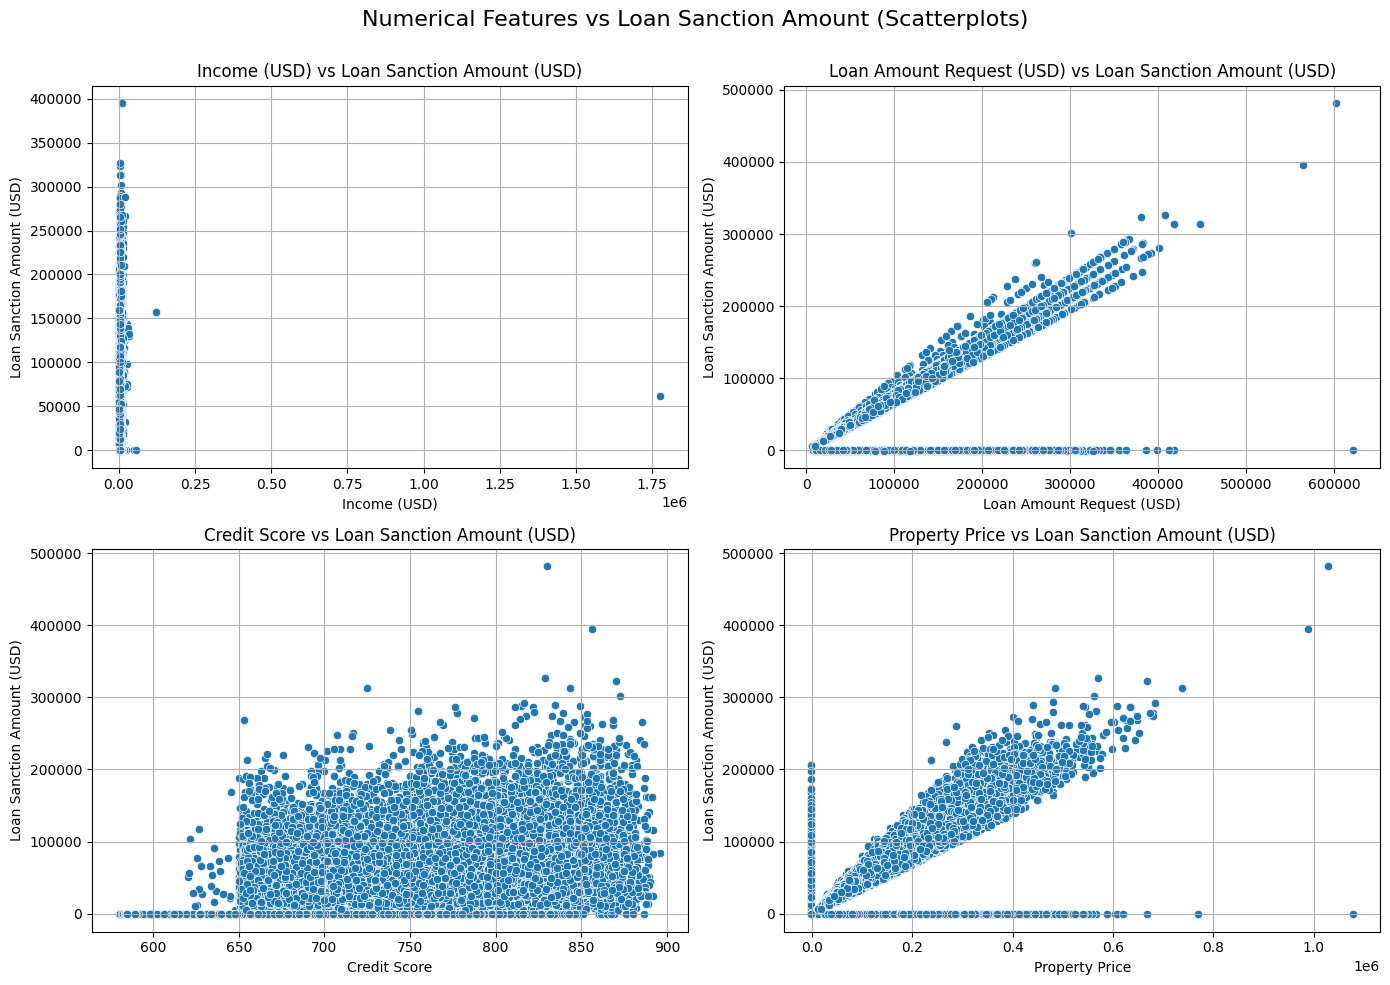

In [10]:
target_col = "Loan Sanction Amount (USD)"

# Select 4 numerical features
numerical_cols = [
    "Income (USD)",
    "Loan Amount Request (USD)",
    "Credit Score",
    "Property Price"
]

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

fig.suptitle(
    "Numerical Features vs Loan Sanction Amount (Scatterplots)\n",
    fontsize=16
)

for i, col in enumerate(numerical_cols):
    sns.scatterplot(
        data=train,
        x=col,
        y=target_col,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} vs {target_col}")
    axes[i].grid(True)

plt.tight_layout()
plt.savefig("EX_3/scatterPlots.png", dpi=150)
plt.show()

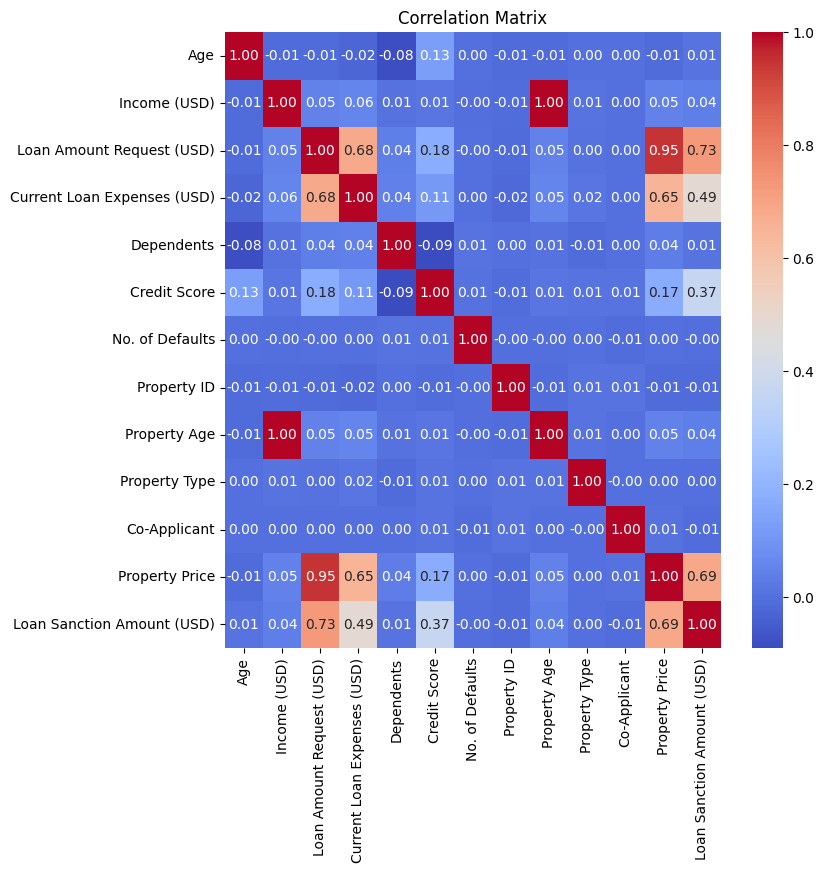

In [11]:
numeric_df = train.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [12]:

target_col = "Loan Sanction Amount (USD)"

X_train = train.drop(columns=[target_col])
y_train = train[target_col]

In [13]:

cols_to_drop = [
    "Name",
    "Customer ID",
    "Property ID"
]

target_col = "Loan Sanction Amount (USD)"

X_train = train.drop(columns=cols_to_drop + [target_col])
y_train = train[target_col]

test = test.drop(columns=cols_to_drop)

In [14]:

numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns

In [15]:

numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns
print("Numerical cols:\n", numerical_cols)
print("Categorical cols:\n", categorical_cols)

Numerical cols:
 Index(['Age', 'Income (USD)', 'Loan Amount Request (USD)',
       'Current Loan Expenses (USD)', 'Dependents', 'Credit Score',
       'No. of Defaults', 'Property Age', 'Property Type', 'Co-Applicant',
       'Property Price'],
      dtype='object')
Categorical cols:
 Index(['Gender', 'Income Stability', 'Profession', 'Type of Employment',
       'Location', 'Expense Type 1', 'Expense Type 2',
       'Has Active Credit Card', 'Property Location'],
      dtype='object')


In [16]:
import numpy as np

# Replace '?' with np.nan in both train and test
X_train.replace("?", np.nan, inplace=True)
test.replace("?", np.nan, inplace=True)
for col in numerical_cols:
    X_train[col] = X_train[col].astype(float)
    test[col]  = test[col].astype(float)
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median", add_indicator=True)

X_train_num = num_imputer.fit_transform(X_train[numerical_cols])
X_test_num  = num_imputer.transform(test[numerical_cols])
from sklearn.preprocessing import OneHotEncoder

cat_imputer = SimpleImputer(strategy="constant", fill_value="Missing")
X_train_cat = cat_imputer.fit_transform(X_train[categorical_cols])
X_test_cat  = cat_imputer.transform(test[categorical_cols])

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(X_train_cat)
X_test_cat  = encoder.transform(X_test_cat)
import numpy as np

# Training set
X_train_final = np.hstack([X_train_num, X_train_cat])

# Test set
X_test_final = np.hstack([X_test_num, X_test_cat])
np.isnan(X_train_final).sum(), np.isnan(X_test_final).sum()
(0, 0)
X_train_sub, X_temp, y_train_sub, y_temp = train_test_split(
    X_train_final, y_train, test_size=0.2, random_state=42
)

X_val, X_test_sub, y_val, y_test_sub = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train size:", X_train_sub.shape)
print("Validation size:", X_val.shape)
print("Internal test size:", X_test_sub.shape)

Train size: (23728, 64)
Validation size: (2966, 64)
Internal test size: (2966, 64)


In [17]:
model = LinearRegression()
model.fit(X_train_sub, y_train_sub)

y_val_pred = model.predict(X_val)

In [18]:
y_val_pred  = model.predict(X_val)
y_test_pred = model.predict(X_test_sub)

# --- Validation Metrics ---
val_mae  = mean_absolute_error(y_val, y_val_pred)
val_mse  = mean_squared_error(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2   = r2_score(y_val, y_val_pred)

print("Validation Metrics:")
print(f"MAE : {val_mae:.2f}")
print(f"MSE : {val_mse:.2f}")
print(f"RMSE: {val_rmse:.2f}")
print(f"R²  : {val_r2:.4f}")

# --- Test Metrics (internal test set) ---
test_mae  = mean_absolute_error(y_test_sub, y_test_pred)
test_mse  = mean_squared_error(y_test_sub, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2   = r2_score(y_test_sub, y_test_pred)

print("\nInternal Test Metrics:")
print(f"MAE : {test_mae:.2f}")
print(f"MSE : {test_mse:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R²  : {test_r2:.4f}")

Validation Metrics:
MAE : 21076.19
MSE : 996620088.64
RMSE: 31569.29
R²  : 0.5471

Internal Test Metrics:
MAE : 21455.74
MSE : 985417974.48
RMSE: 31391.37
R²  : 0.5786


In [19]:
model = LinearRegression()

cv_scores = cross_val_score(
    model,
    X_train_final,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())

CV R² scores: [0.57497115 0.58435124 0.58567337 0.5811299  0.62427585]
Mean CV R²: 0.5900803006737141


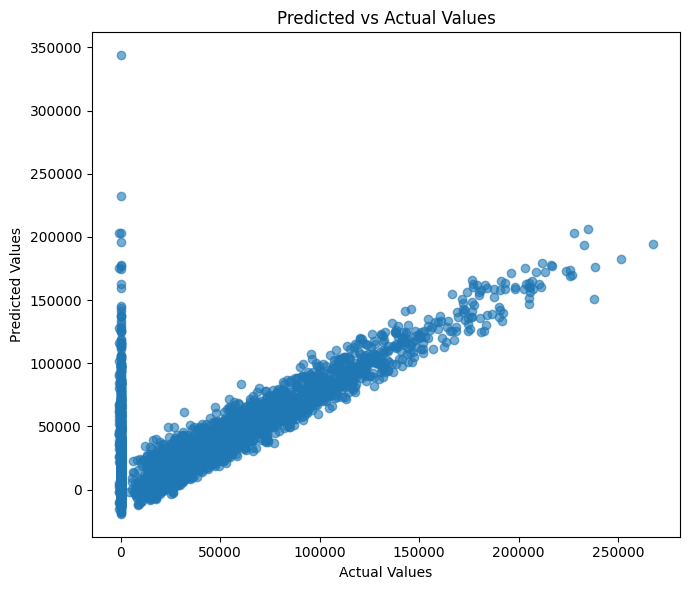

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(y_val, y_val_pred, alpha=0.6)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")

plt.tight_layout()
plt.savefig("EX_3/linearPreVsAct.png", dpi=150)
plt.show()

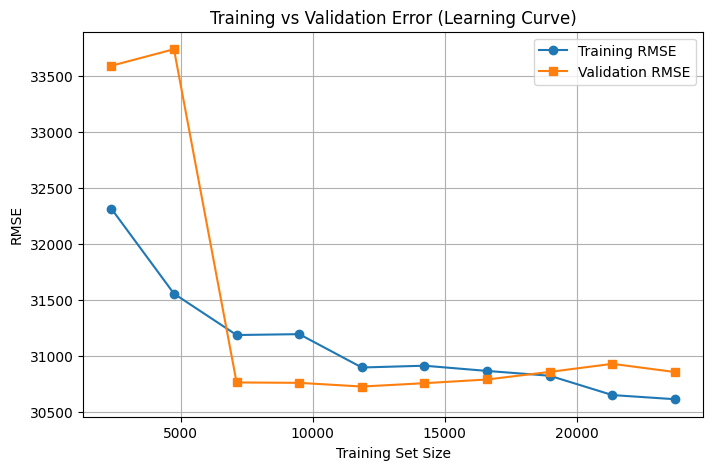

In [22]:
from sklearn.model_selection import learning_curve
model = LinearRegression()

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_final,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Convert negative MSE to RMSE
train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse   = np.sqrt(-val_scores.mean(axis=1))

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, marker='o', label="Training RMSE")
plt.plot(train_sizes, val_rmse, marker='s', label="Validation RMSE")

plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.title("Training vs Validation Error (Learning Curve)")
plt.legend()
plt.grid(True)
plt.savefig("EX_3/TrainVsValid.png", dpi=150)
plt.show()

In [23]:
model = LinearRegression()

param_grid = {
    "fit_intercept": [True, False]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,              # ⬅️ validation via CV
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_final, y_train)

,estimator,LinearRegression()
,param_grid,"{'fit_intercept': [True, False]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,fit_intercept,True


In [24]:
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}

ridge = Ridge(random_state=42)
ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# --- Train on training split ---
start_time = time.time()
ridge_grid.fit(X_train_sub, y_train_sub)
end_time = time.time()
ridge_training_time = end_time - start_time

ridge_best_model = ridge_grid.best_estimator_

# --- CV score ---
ridge_best_cv_r2 = ridge_grid.best_score_

# --- Predictions & Metrics ---

# Validation set
y_val_pred_ridge = ridge_best_model.predict(X_val)
val_mae  = mean_absolute_error(y_val, y_val_pred_ridge)
val_mse  = mean_squared_error(y_val, y_val_pred_ridge)
val_rmse = np.sqrt(val_mse)
val_r2   = r2_score(y_val, y_val_pred_ridge)

# Internal Test set
y_test_pred_ridge = ridge_best_model.predict(X_test_sub)
test_mae  = mean_absolute_error(y_test_sub, y_test_pred_ridge)
test_mse  = mean_squared_error(y_test_sub, y_test_pred_ridge)
test_rmse = np.sqrt(test_mse)
test_r2   = r2_score(y_test_sub, y_test_pred_ridge)

# --- Print Results ---
print("Ridge Regression - Hyperparameter Tuning Results\n")
print("Best Parameters:", ridge_grid.best_params_)
print("Best CV R²      :", ridge_best_cv_r2)
print("\nValidation Metrics:")
print(f"MAE : {val_mae:.2f}")
print(f"MSE : {val_mse:.2f}")
print(f"RMSE: {val_rmse:.2f}")
print(f"R²  : {val_r2:.4f}")
print("\nInternal Test Metrics:")
print(f"MAE : {test_mae:.2f}")
print(f"MSE : {test_mse:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R²  : {test_r2:.4f}")
print("\nTraining Time (s):", ridge_training_time)

Ridge Regression - Hyperparameter Tuning Results

Best Parameters: {'alpha': 100}
Best CV R²      : 0.5903934865543382

Validation Metrics:
MAE : 21059.20
MSE : 996252018.36
RMSE: 31563.46
R²  : 0.5473

Internal Test Metrics:
MAE : 21453.35
MSE : 985278689.47
RMSE: 31389.15
R²  : 0.5787

Training Time (s): 2.470799207687378


In [25]:
from sklearn.linear_model import Lasso

# --- Hyperparameter Grid ---
lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

lasso = Lasso(random_state=42)
lasso_grid = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# --- Train ---
start_time = time.time()
lasso_grid.fit(X_train_sub, y_train_sub)
end_time = time.time()
lasso_training_time = end_time - start_time

lasso_best_model = lasso_grid.best_estimator_

# --- CV score ---
lasso_best_cv_r2 = lasso_grid.best_score_

# --- Predictions & Metrics ---
# Validation set
y_val_pred_lasso = lasso_best_model.predict(X_val)
val_mae  = mean_absolute_error(y_val, y_val_pred_lasso)
val_mse  = mean_squared_error(y_val, y_val_pred_lasso)
val_rmse = np.sqrt(val_mse)
val_r2   = r2_score(y_val, y_val_pred_lasso)

# Internal Test set
y_test_pred_lasso = lasso_best_model.predict(X_test_sub)
test_mae  = mean_absolute_error(y_test_sub, y_test_pred_lasso)
test_mse  = mean_squared_error(y_test_sub, y_test_pred_lasso)
test_rmse = np.sqrt(test_mse)
test_r2   = r2_score(y_test_sub, y_test_pred_lasso)

# --- Print Results ---
print("Lasso Regression - Hyperparameter Tuning Results\n")
print("Best Parameters:", lasso_grid.best_params_)
print("Best CV R²      :", lasso_best_cv_r2)
print("\nValidation Metrics:")
print(f"MAE : {val_mae:.2f}")
print(f"MSE : {val_mse:.2f}")
print(f"RMSE: {val_rmse:.2f}")
print(f"R²  : {val_r2:.4f}")
print("\nInternal Test Metrics:")
print(f"MAE : {test_mae:.2f}")
print(f"MSE : {test_mse:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R²  : {test_r2:.4f}")
print("\nTraining Time (s):", lasso_training_time)

Lasso Regression - Hyperparameter Tuning Results

Best Parameters: {'alpha': 10}
Best CV R²      : 0.5907351221335052

Validation Metrics:
MAE : 21055.48
MSE : 995319953.01
RMSE: 31548.69
R²  : 0.5477

Internal Test Metrics:
MAE : 21458.80
MSE : 985098230.58
RMSE: 31386.27
R²  : 0.5788

Training Time (s): 31.914673805236816


C:\Users\jayas\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.099e+13, tolerance: 5.550e+09
  model = cd_fast.enet_coordinate_descent(


In [26]:
from sklearn.linear_model import ElasticNet

# --- Hyperparameter Grid ---
elastic_params = {
    'alpha': [0.01, 0.1, 1, 10],
    'l1_ratio': [0.2, 0.5, 0.8]
}

elastic = ElasticNet(random_state=42)
elastic_grid = GridSearchCV(
    elastic,
    elastic_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# --- Train ---
start_time = time.time()
elastic_grid.fit(X_train_sub, y_train_sub)
end_time = time.time()
elastic_training_time = end_time - start_time

elastic_best_model = elastic_grid.best_estimator_

# --- CV score ---
elastic_best_cv_r2 = elastic_grid.best_score_

# --- Predictions & Metrics ---
# Validation set
y_val_pred_elastic = elastic_best_model.predict(X_val)
val_mae  = mean_absolute_error(y_val, y_val_pred_elastic)
val_mse  = mean_squared_error(y_val, y_val_pred_elastic)
val_rmse = np.sqrt(val_mse)
val_r2   = r2_score(y_val, y_val_pred_elastic)

# Internal Test set
y_test_pred_elastic = elastic_best_model.predict(X_test_sub)
test_mae  = mean_absolute_error(y_test_sub, y_test_pred_elastic)
test_mse  = mean_squared_error(y_test_sub, y_test_pred_elastic)
test_rmse = np.sqrt(test_mse)
test_r2   = r2_score(y_test_sub, y_test_pred_elastic)

# --- Print Results ---
print("ElasticNet Regression - Hyperparameter Tuning Results\n")
print("Best Parameters:", elastic_grid.best_params_)
print("Best CV R²      :", elastic_best_cv_r2)
print("\nValidation Metrics:")
print(f"MAE : {val_mae:.2f}")
print(f"MSE : {val_mse:.2f}")
print(f"RMSE: {val_rmse:.2f}")
print(f"R²  : {val_r2:.4f}")
print("\nInternal Test Metrics:")
print(f"MAE : {test_mae:.2f}")
print(f"MSE : {test_mse:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"R²  : {test_r2:.4f}")
print("\nTraining Time (s):", elastic_training_time)

ElasticNet Regression - Hyperparameter Tuning Results

Best Parameters: {'alpha': 0.1, 'l1_ratio': 0.8}
Best CV R²      : 0.5905318694714017

Validation Metrics:
MAE : 21038.70
MSE : 996509542.46
RMSE: 31567.54
R²  : 0.5472

Internal Test Metrics:
MAE : 21439.61
MSE : 986018601.12
RMSE: 31400.93
R²  : 0.5784

Training Time (s): 65.7771863937378


C:\Users\jayas\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.103e+13, tolerance: 5.550e+09
  model = cd_fast.enet_coordinate_descent(


In [28]:
import matplotlib.pyplot as plt

def plot_pred_vs_actual(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)
    
    plt.figure(figsize=(6,6))
    plt.scatter(y_val, y_pred, alpha=0.6)
   # plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{model_name} - Predicted vs Actual")
    plt.grid(True)
    #plt.show()
    return plt

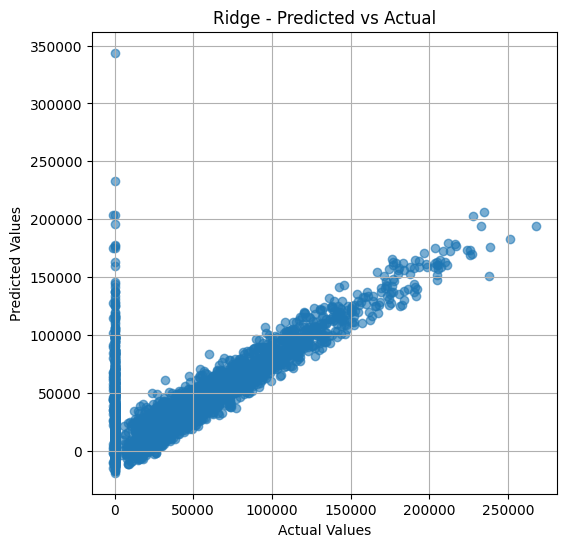

In [29]:
plot_pred_vs_actual(ridge_best_model, X_val, y_val, "Ridge")
plt.savefig("EX_3/RidgePreVsAct.png", dpi=150)

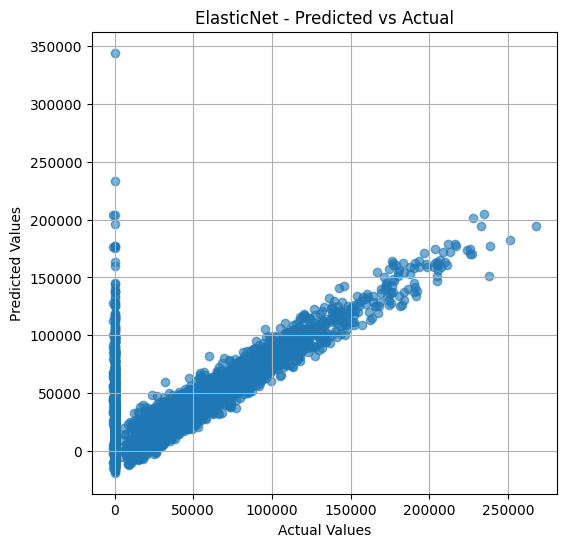

In [30]:
plot_pred_vs_actual(elastic_best_model, X_val, y_val, "ElasticNet")
plt.savefig("EX_3/ElasticPreVsAct.png", dpi=150)

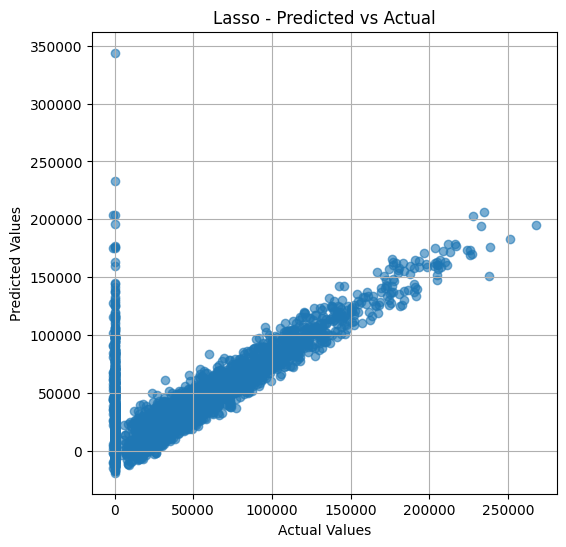

In [31]:
plot_pred_vs_actual(lasso_best_model, X_val, y_val, "Lasso")
plt.savefig("EX_3/LassoPreVsAct.png", dpi=150)

In [34]:
def plot_learning_curve(model, X_train, y_train, model_name, scoring='neg_mean_absolute_error'):
    from sklearn.model_selection import learning_curve
    import matplotlib.pyplot as plt
    import numpy as np

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train,
        y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    
    # Compute mean (ignore std)
    train_scores_mean = -np.mean(train_scores, axis=1)
    val_scores_mean   = -np.mean(val_scores, axis=1)
    
    # Plot
    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Training Error')
    plt.plot(train_sizes, val_scores_mean, 'o-', color='orange', label='Validation Error')
    
    plt.xlabel("Training Set Size")
    plt.ylabel("MAE")
    plt.title(f"{model_name} - Learning Curve (MAE)")
    plt.legend(loc='best')
    plt.grid(True)
    #plt.show()
    return plt

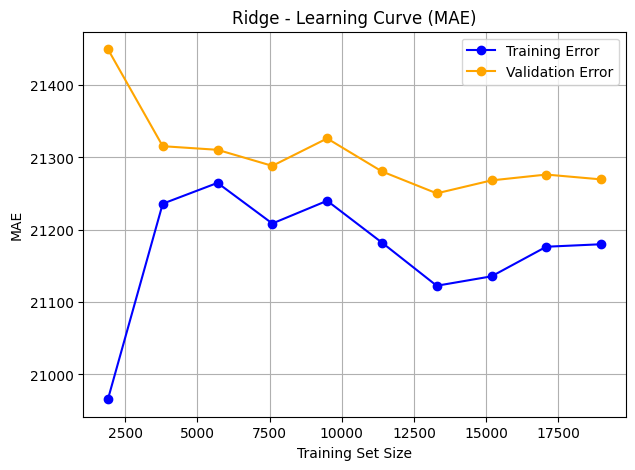

In [36]:
plot_learning_curve(ridge_best_model, X_train_sub, y_train_sub, "Ridge")
plt.savefig("EX_3/RidgeTrainVsValid.png", dpi=150)

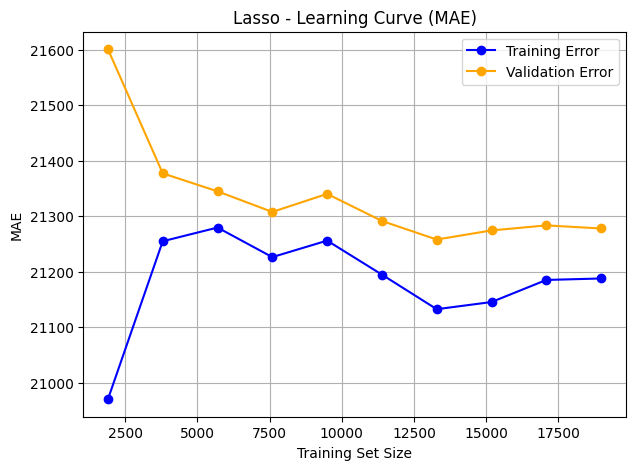

In [37]:

plot_learning_curve(lasso_best_model, X_train_sub, y_train_sub, "Lasso")
plt.savefig("EX_3/LassoTrainVsValid.png", dpi=150)

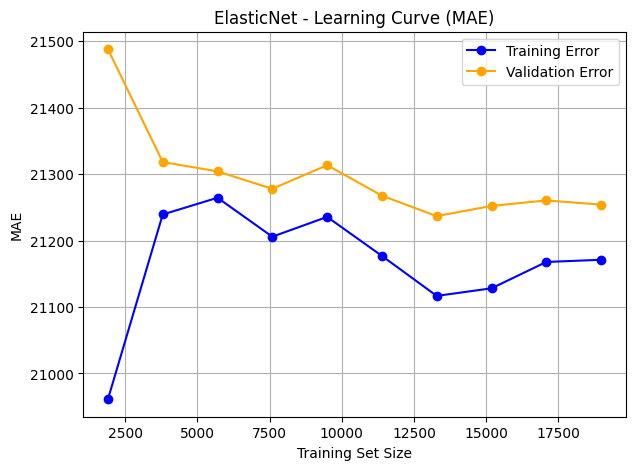

In [38]:
plot_learning_curve(elastic_best_model, X_train_sub, y_train_sub, "ElasticNet")
plt.savefig("EX_3/ElasticTrainVsValid.png", dpi=150)